In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

<h3>Загружаем датасет</h3>

In [144]:
# dataset https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students

df = pd.read_csv('../data/ai_student_impact.csv')

In [145]:
df.head(20)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [146]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

<h3>Очистка данных</h3>

In [147]:
# Обозначим категориальные столбцы

categorical_cols = [
    'Major_Category', 
    'Year_of_Study', 
    'Primary_Use_Case',
    'Prompt_Engineering_Skill', 
    'Institutional_Policy',
    'Burnout_Risk_Level'
]

df[categorical_cols] = df[categorical_cols].astype('category')

df['Year_of_Study'] = df['Year_of_Study'].cat.reorder_categories(
    ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'], ordered=True)
df['Prompt_Engineering_Skill'] = df['Prompt_Engineering_Skill'].cat.reorder_categories(
    ['Beginner', 'Intermediate', 'Advanced'], ordered=True)
df['Burnout_Risk_Level'] = df['Burnout_Risk_Level'].cat.reorder_categories(
    ['Low', 'Medium', 'High'], ordered=True)

In [148]:
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 3.77 MB


In [149]:
# Даункаст

df['Student_ID'] = df['Student_ID'].astype('int32')
df['Tool_Diversity'] = df['Tool_Diversity'].astype('int8')
df['Perceived_AI_Dependency'] = df['Perceived_AI_Dependency'].astype('int8')
df['Anxiety_Level_During_Exams'] = df['Anxiety_Level_During_Exams'].astype('int8')

float_cols = [
    'Pre_Semester_GPA',
    'Post_Semester_GPA',
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Skill_Retention_Score'
]
df[float_cols] = df[float_cols].astype('float32')


In [150]:
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 1.62 MB


In [151]:
df = df.drop(columns = ['Student_ID'])
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 1.43 MB


In [152]:
# Уберем некоторые краевые значения

# df = df[df['Skill_Retention_Score'].between(20, 95)]
# df = df[df['Weekly_GenAI_Hours'].between(0, 38)]
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 1.43 MB


<h3>EDA</h3>

In [153]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798126
std,0.478854,8.269489,1.18802,5.156426,1.820812,2.144066,0.495673,13.281627
min,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190002
max,3.998000,40.000000,5.00000,35.860001,10.000000,10.000000,4.000000,100.000000


In [154]:
cat_features = df.select_dtypes(include=['category'])
print(cat_features.columns.to_list())

['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']


In [155]:
num_features = df.select_dtypes(include=[np.number])
print(num_features.columns.to_list())

['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']


In [156]:
for cat in cat_features:
    print(f'{cat} - numer of unique = {df[cat].nunique()}')

Major_Category - numer of unique = 5
Year_of_Study - numer of unique = 5
Primary_Use_Case - numer of unique = 5
Prompt_Engineering_Skill - numer of unique = 3
Institutional_Policy - numer of unique = 3
Burnout_Risk_Level - numer of unique = 3


In [157]:
for col in cat_features:
    print(f'Unique categories in {df[col].value_counts()}\n\n')

Unique categories in Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64


Unique categories in Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64


Unique categories in Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64


Unique categories in Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64


Unique categories in Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64


Unique categories in Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64




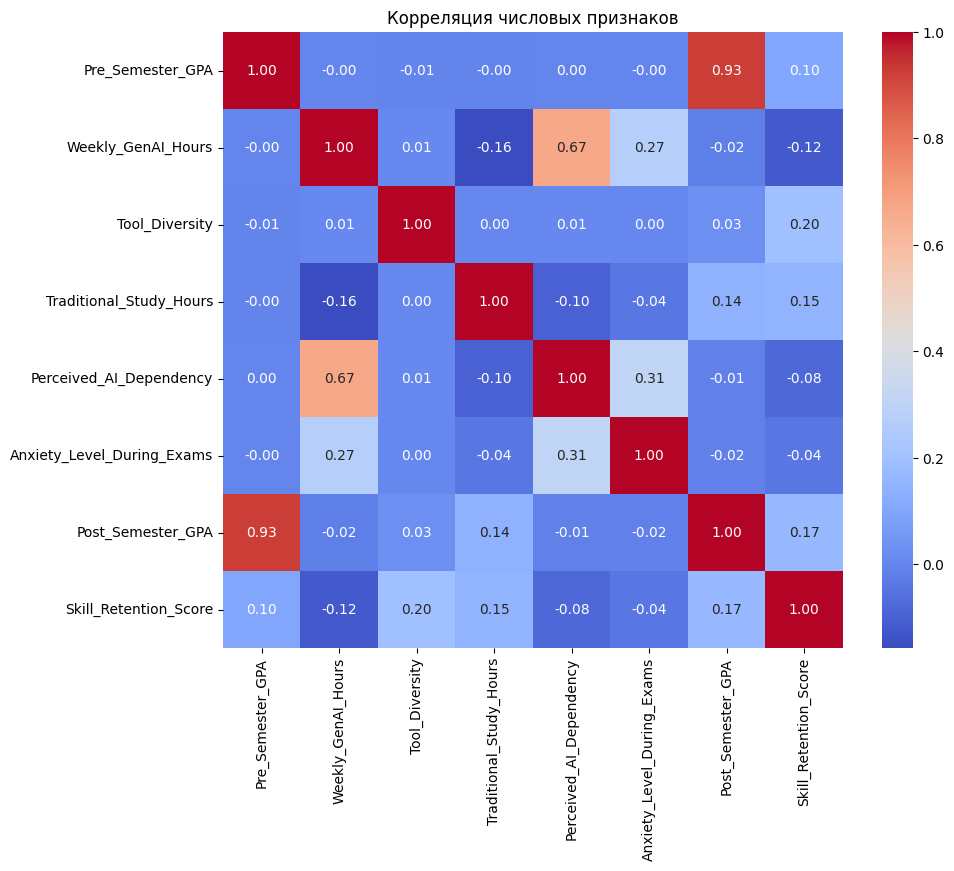

In [158]:
# Корреляция числовых фичей

plt.figure(figsize=(10, 8))
feature_correlation = num_features.corr()
sns.heatmap(feature_correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых признаков')
plt.show()

Корреляции:
- Очевидная зависимость оценки в начале семестра и в конце (Pre/Post_Semester_GPA)
- Большая корреляция Зависимости студента от ИИ и часов использования ИИ (Weekly_GenAI_Hours и Perceived_AI_Dependency)

<p></p>

- Skill_Retention_Score прямо зависит от оценок в начале семестра и в конце (Pre/Post_Semester_GPA)
- Skill_Retention_Score прямо зависит от количества разных используемых ИИ инструментов (Tool_Diversity)
- Skill_Retention_Score обратная зависимость от кол-ва часов использования ИИ (Weekly_GenAI_Hours) и прямо от традиционных часов на учебу (Traditional_Study_Hours)

<p></p>


- Прямая корреляция часов использования ИИ/Зависимости от ИИ и степени тревожности на экзамене (Weekly_GenAI_Hours/Perceived_AI_Dependency и Anxiety_Level_During_Exams)
- Обратная корреляция часов использования ИИ и традиционных часов на учебу (Weekly_GenAI_Hours и Traditional_Study_Hours)

<p></p>

<b>Можем предположить, что использование ИИ обратно сказывается на успеваемости студента с точки зрения усваивания знаний по предмету, а также повышает тревожность на экзамене. 

In [159]:
print(num_features.columns.to_list())

['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']


In [160]:
print(cat_features.columns.to_list())

['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']


C:\Users\User\AppData\Local\Temp\ipykernel_18780\2665855403.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_18780\2665855403.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_18780\2665855403.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


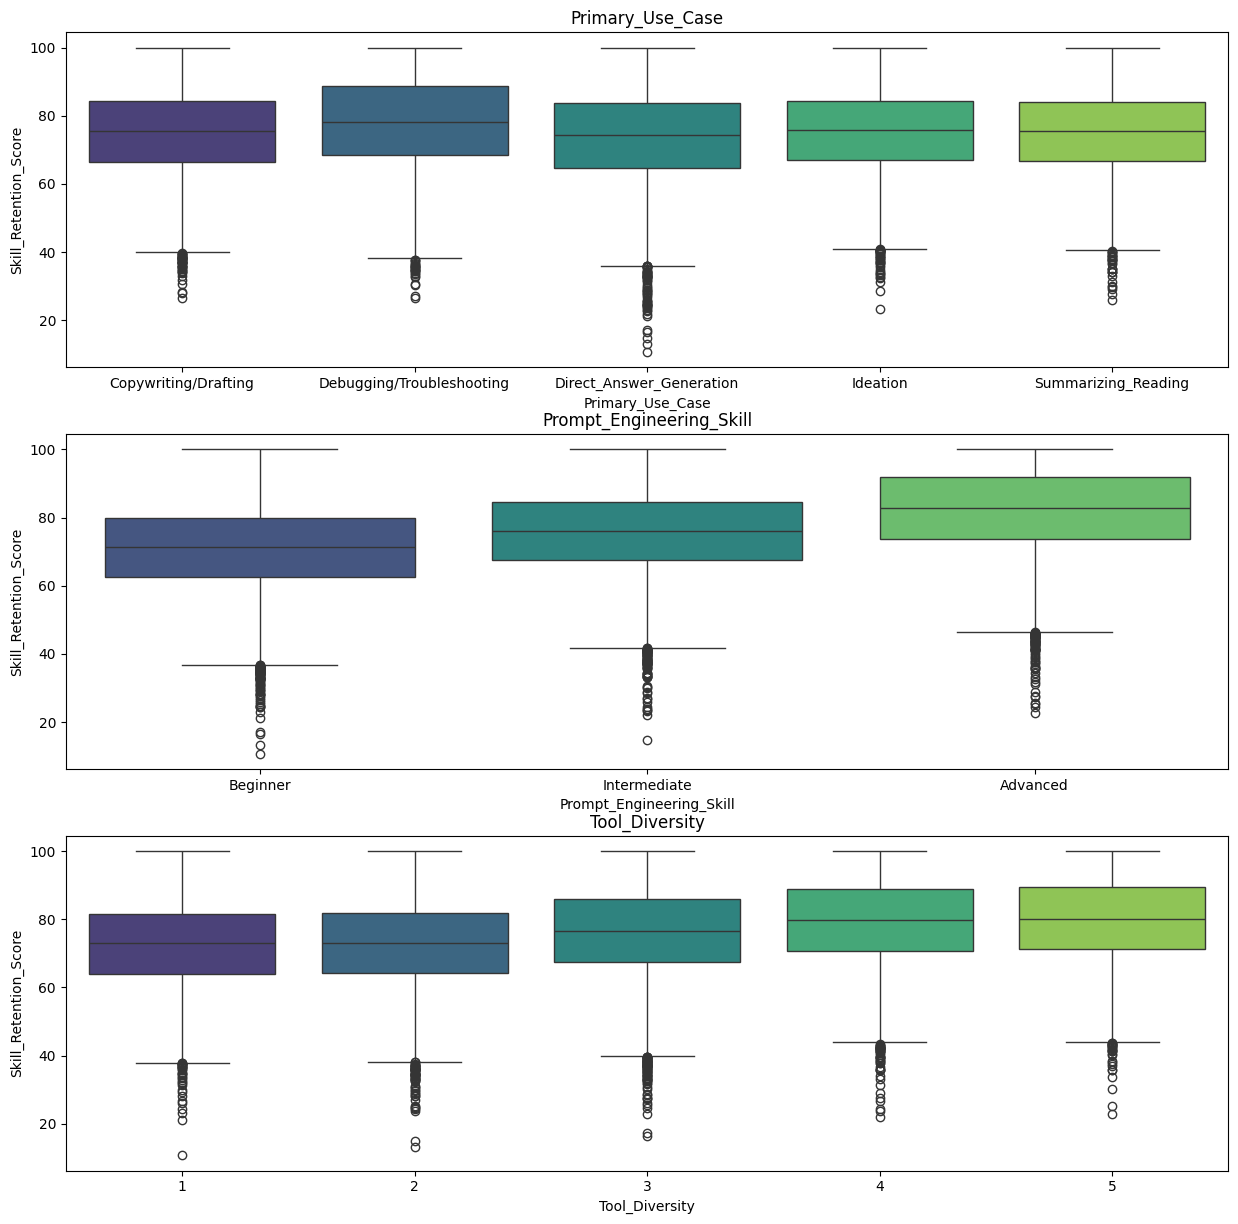

In [161]:
# Ящики с усами по категорияльным признакам и Skill_Retention_Score

plt.figure(figsize=(15, 20))

cols = [
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Tool_Diversity'
]

for num, col in enumerate(cols):
    plt.subplot(4, 1, num+1)
    sns.boxplot(
            data=df,
            x=col,
            y="Skill_Retention_Score",
            palette="viridis",
        )
    plt.title(col)

plt.show()

Заметим, что худший результат показали студенты, использующие ИИ для получения конечного ответа. Они же показали наибольшее кол-во выбросов с низким усвоением материала.<p>
Но студенты, обладающие лучшими навыками владения ИИ и использующие больше разнообразных инструментов, имеют лучшие результаты.<p>
<b>Предположим, что бездумное использование ИИ ухудшает усвоение материала, а умелое напротив - повышает результативность.

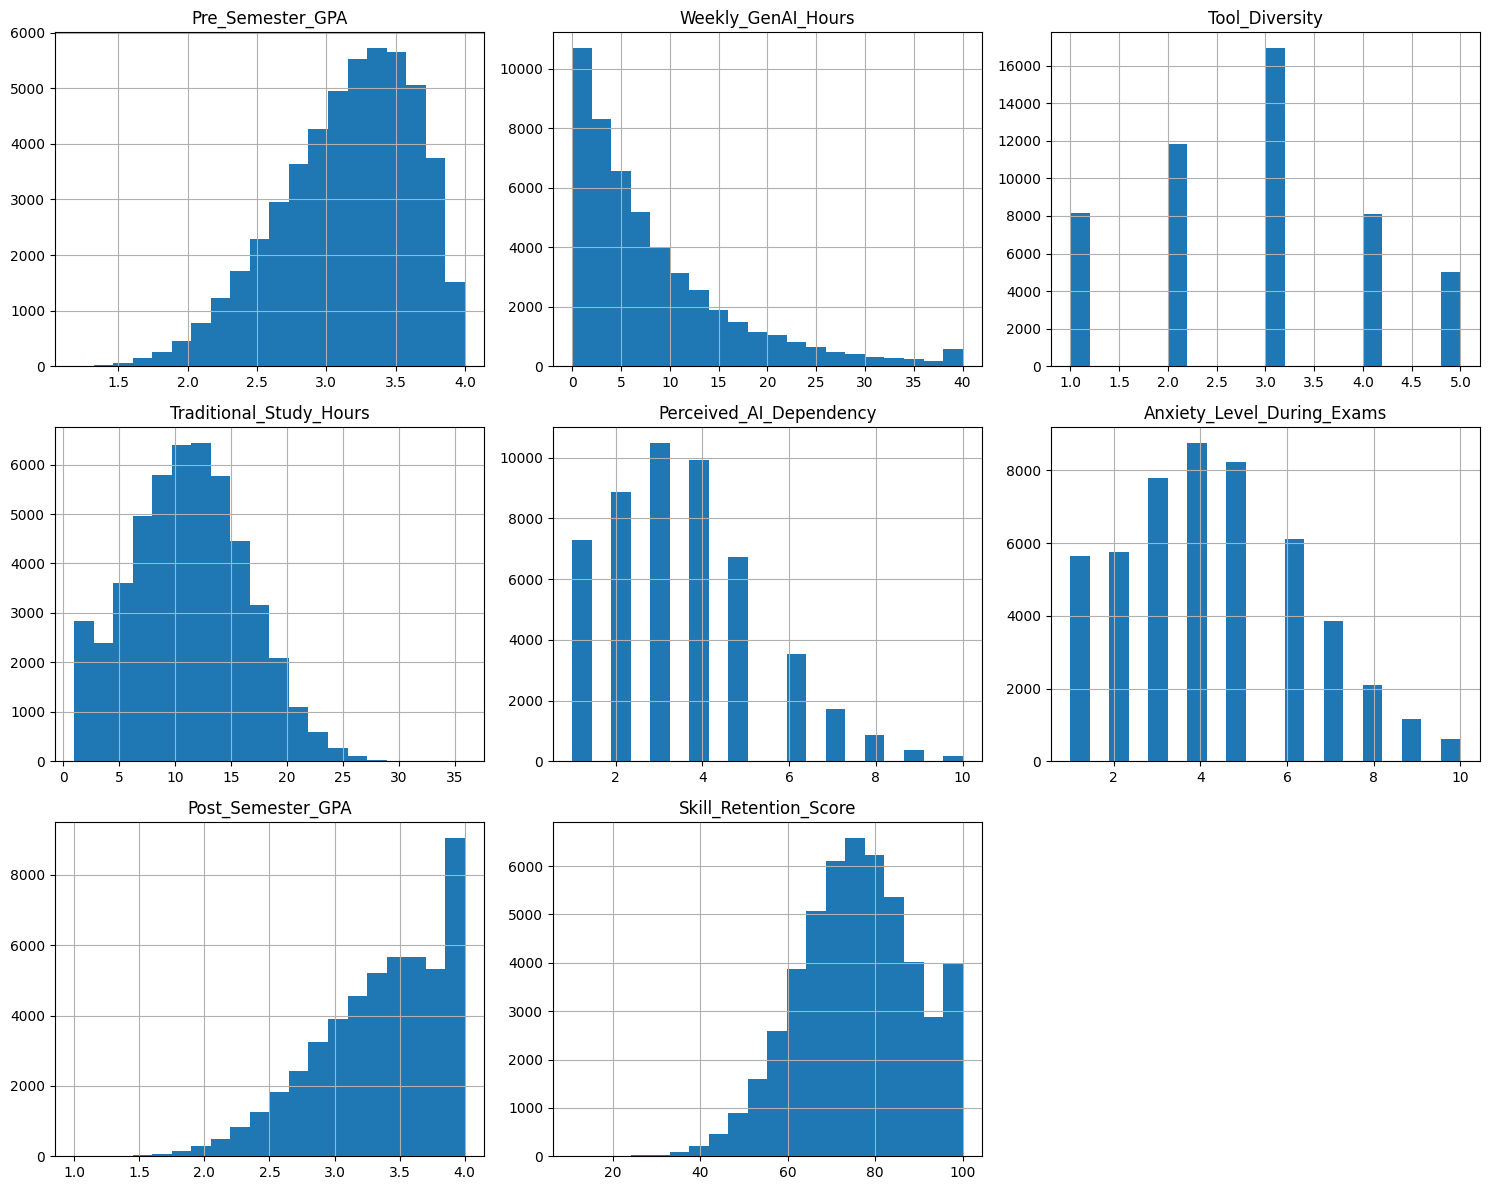

In [162]:
# Гистограммы по числовым признакам

df.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

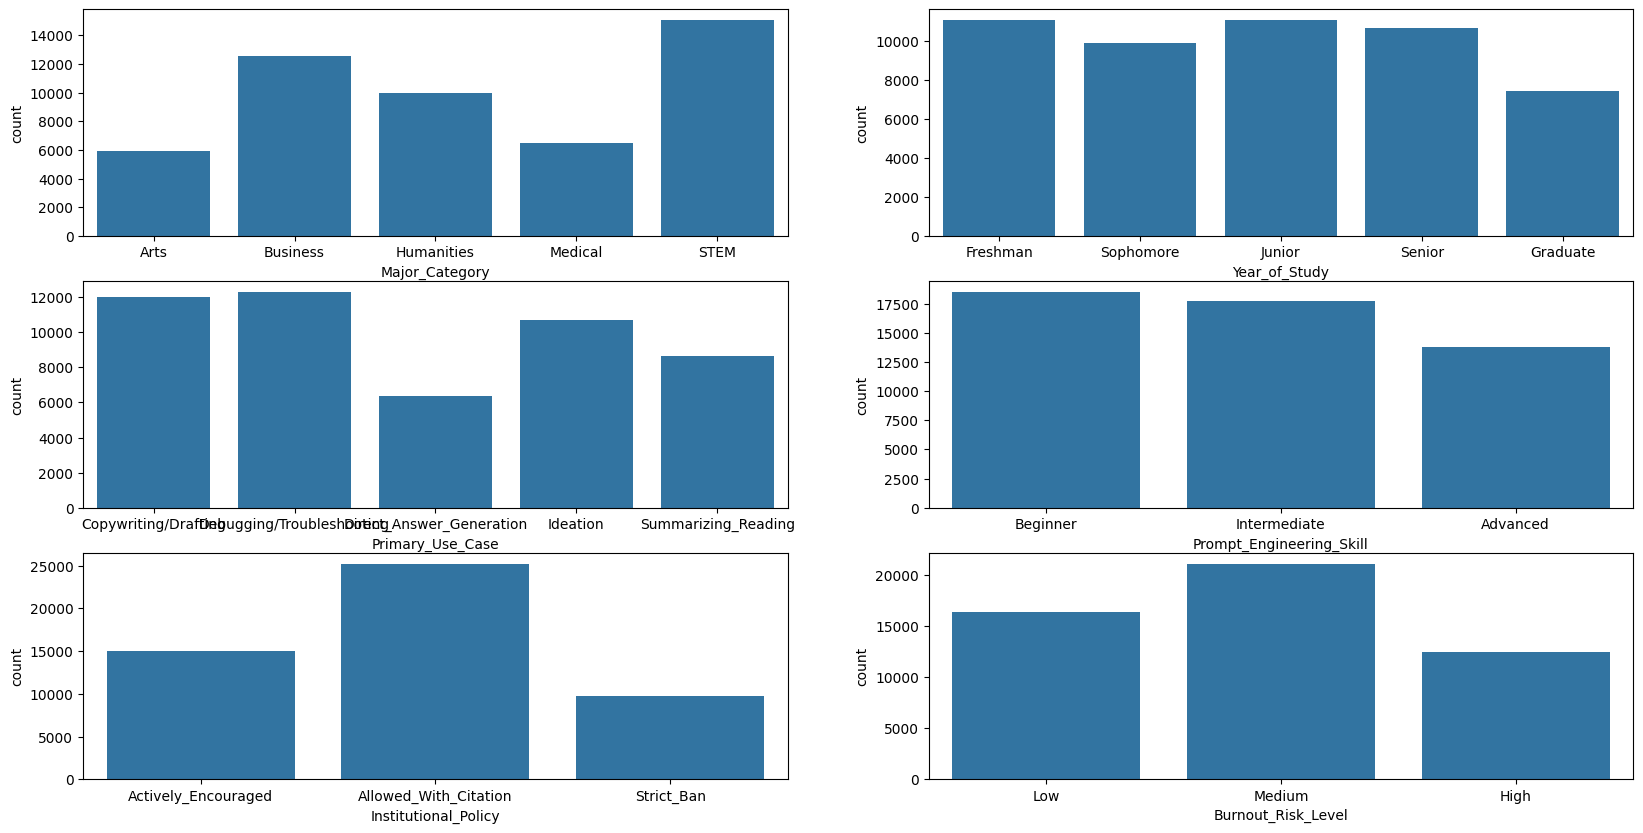

In [163]:
# Countplot по категорийным признакам

plt.figure(figsize=(20, 10))
for i, col in enumerate(df.select_dtypes('category').columns):
    plt.subplot(3,2,i+1)
    sns.countplot(data=df, x=col)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_18780\3250317331.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_18780\3250317331.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0.5, 1.0, 'Burnout_Risk_Level - Weekly_GenAI_Hours')

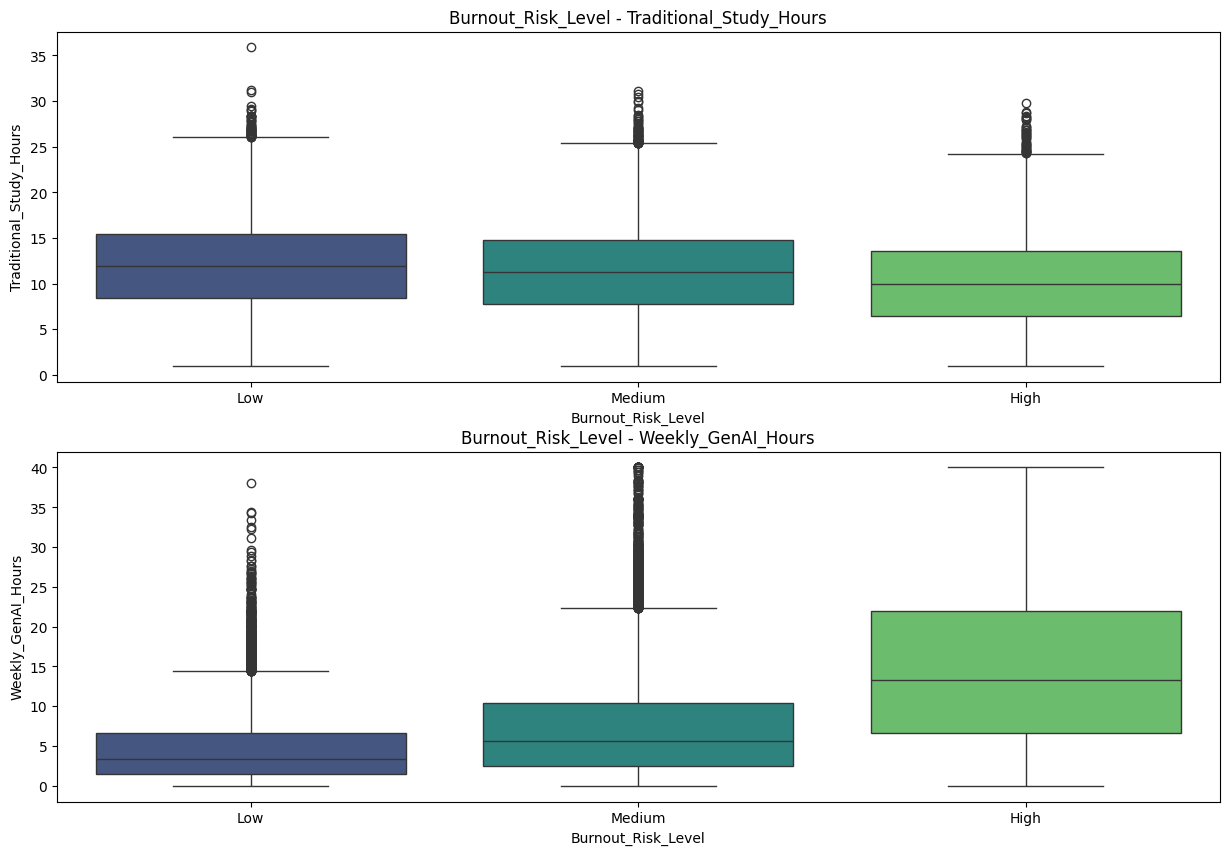

In [164]:
# Ящики с усами - время традиционного обучения и с ИИ

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
sns.boxplot(
        data=df,
        x='Burnout_Risk_Level',
        y="Traditional_Study_Hours",
        palette="viridis",
    )
plt.title('Burnout_Risk_Level - Traditional_Study_Hours')

plt.subplot(2, 1, 2)
sns.boxplot(
        data=df,
        x='Burnout_Risk_Level',
        y="Weekly_GenAI_Hours",
        palette="viridis",
    )
plt.title('Burnout_Risk_Level - Weekly_GenAI_Hours')

<b>Студенты черезмерно использующие ИИ имеют высокую степень риска выгорания

In [165]:
num_features = df.select_dtypes(include=[np.number])
print(num_features.columns.to_list())

['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']


C:\Users\User\AppData\Local\Temp\ipykernel_18780\2944600634.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\User\AppData\Local\Temp\ipykernel_18780\2944600634.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


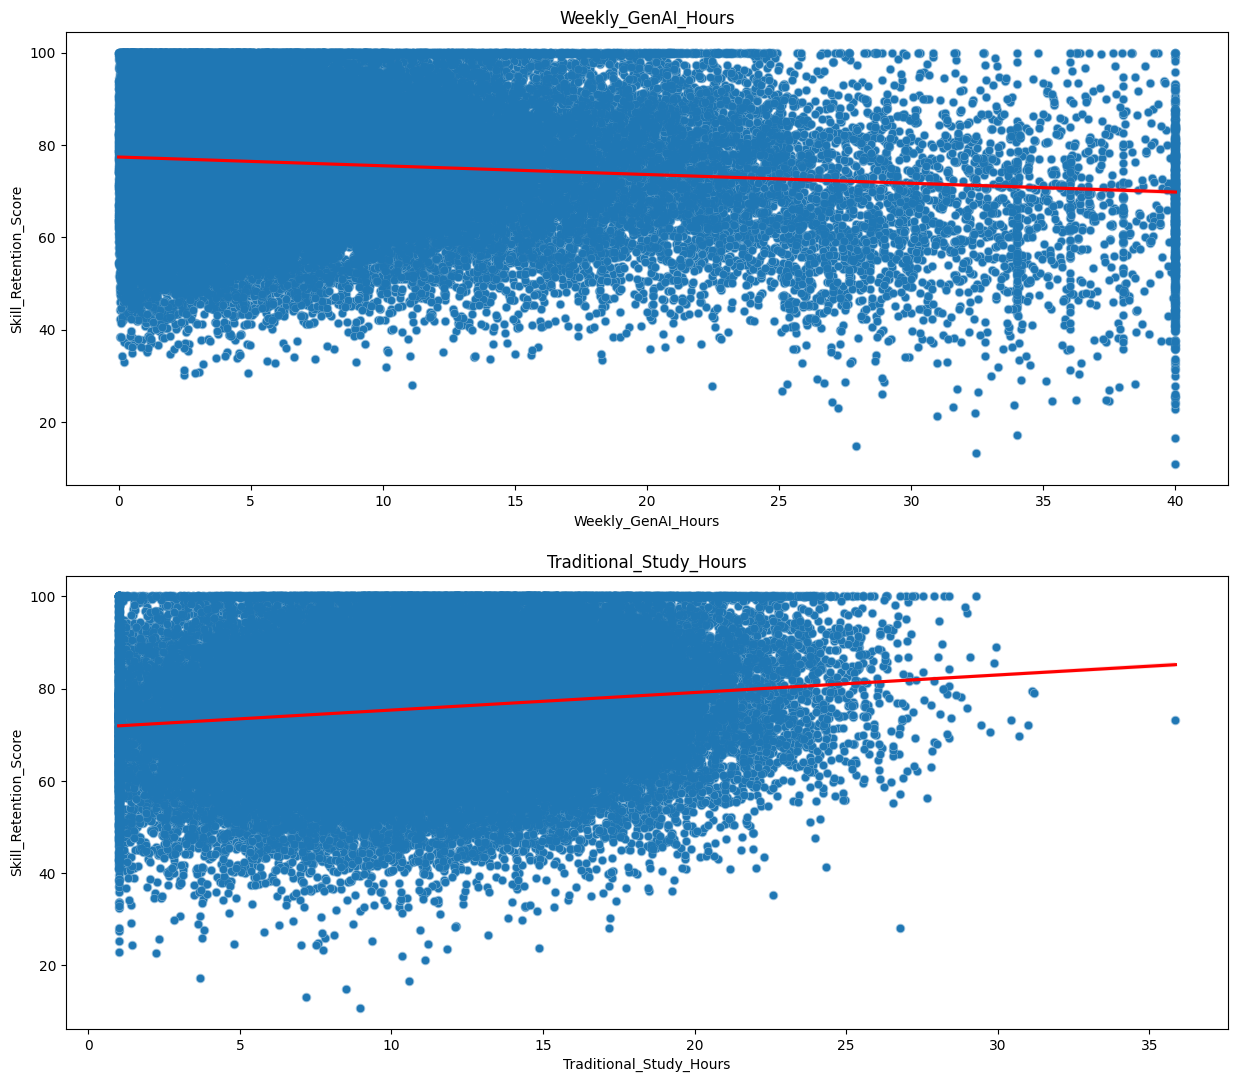

In [166]:
# Зависимость времени традиционного обучения и использования ИИ на усвоение материала

plt.figure(figsize=(15, 20))

cols = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
]

for num, col in enumerate(cols):
    plt.subplot(3, 1, num+1)
    sns.scatterplot(
            data=df,
            x=col,
            y="Skill_Retention_Score",
            # y="Post_Semester_GPA",
            palette="viridis",
        )
    sns.regplot(
        data=df, 
        x=col, 
        y="Skill_Retention_Score",
        # y="Post_Semester_GPA",
        scatter_kws={'alpha':0.3},
        line_kws={'color': 'red'}
    )
    plt.title(col)

plt.show()

При повышении традиционных часов на обучение повышается и минимальный уровень освоения материала.<p>
При излишнем использовании ИИ (примерно >25ч в неделю) усваиваемость начинает падать.<p>
<b>Предположим, что черезмерное использование ИИ может вредить успеваемости

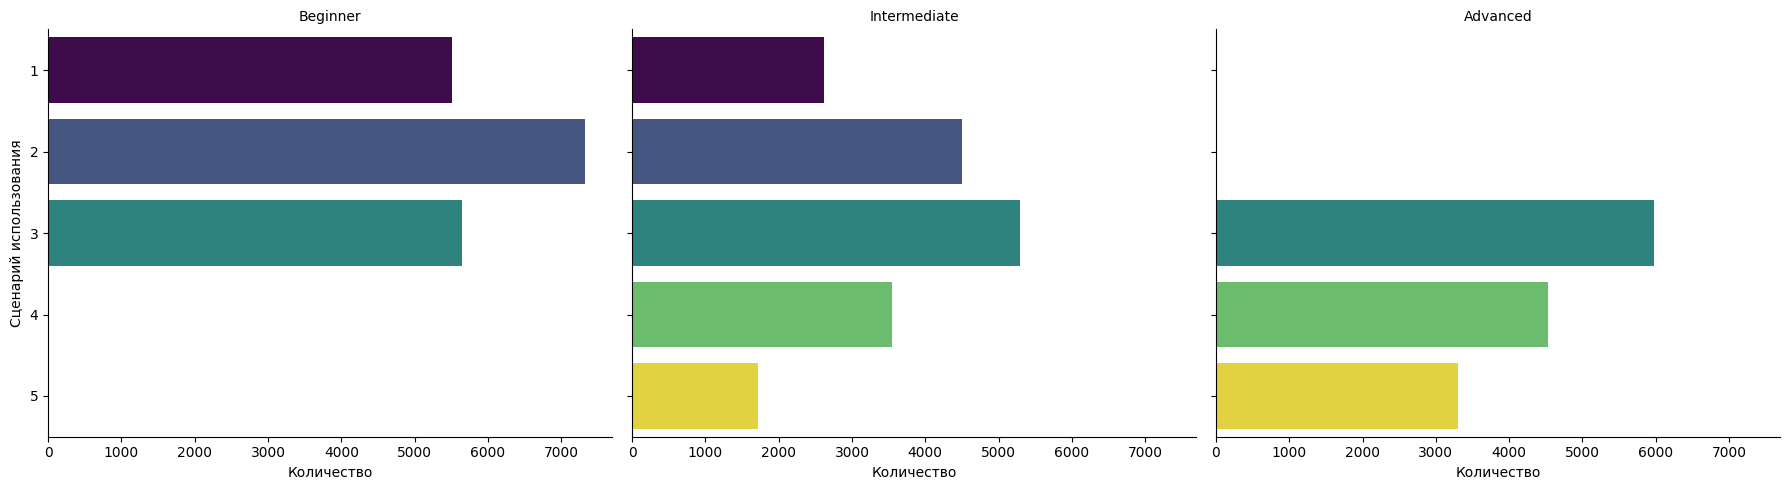

In [167]:
g = sns.catplot(
    data=df,
    y="Tool_Diversity",       # Названия кейсов по вертикали (чтобы текст читался)
    hue="Tool_Diversity",     # Красим каждый кейс в свой цвет (опционально)
    kind="count",               # Считаем количество строк
    col="Prompt_Engineering_Skill", # Для каждого навыка — своя колонка
    col_wrap=3,                 # Если навыков много, переносим на новую строку (например, по 3 в ряд)
    height=5,                   # Высота каждого подграфика
    aspect=1.2,                 # Пропорции (ширина = height * aspect)
    palette="viridis",          # Приятная цветовая палитра
    legend=False                # Отключаем общую легенду, так как оси Y подписаны
)

# Настройка заголовков подграфиков
g.set_titles("{col_name}")
g.set_axis_labels("Количество", "Сценарий использования")

plt.tight_layout()
plt.show()

In [168]:
# Введем новые информативные признаки

df['GPA_Delta'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']     # Разница между началом и концом года
df['Academic_Perfomance_Drop'] = df['GPA_Delta'] < 0                    # Было ли ухудшение успеваемости

df['High_Risk_Student'] = (
    (df['Burnout_Risk_Level'] == 'High') & \
    (df['Anxiety_Level_During_Exams'] > 7)
)                                                                       # Находится ли стундент в зоне риска

df['Total_Stud_Hours'] = df['Traditional_Study_Hours'] + df['Weekly_GenAI_Hours']   # Все время обучения в неделю
df['AI_Usage_Percentage'] = df['Weekly_GenAI_Hours'] / df['Total_Stud_Hours']       # Доля использования ИИ от всего времени обучения

C:\Users\User\AppData\Local\Temp\ipykernel_18780\46561556.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\User\AppData\Local\Temp\ipykernel_18780\46561556.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


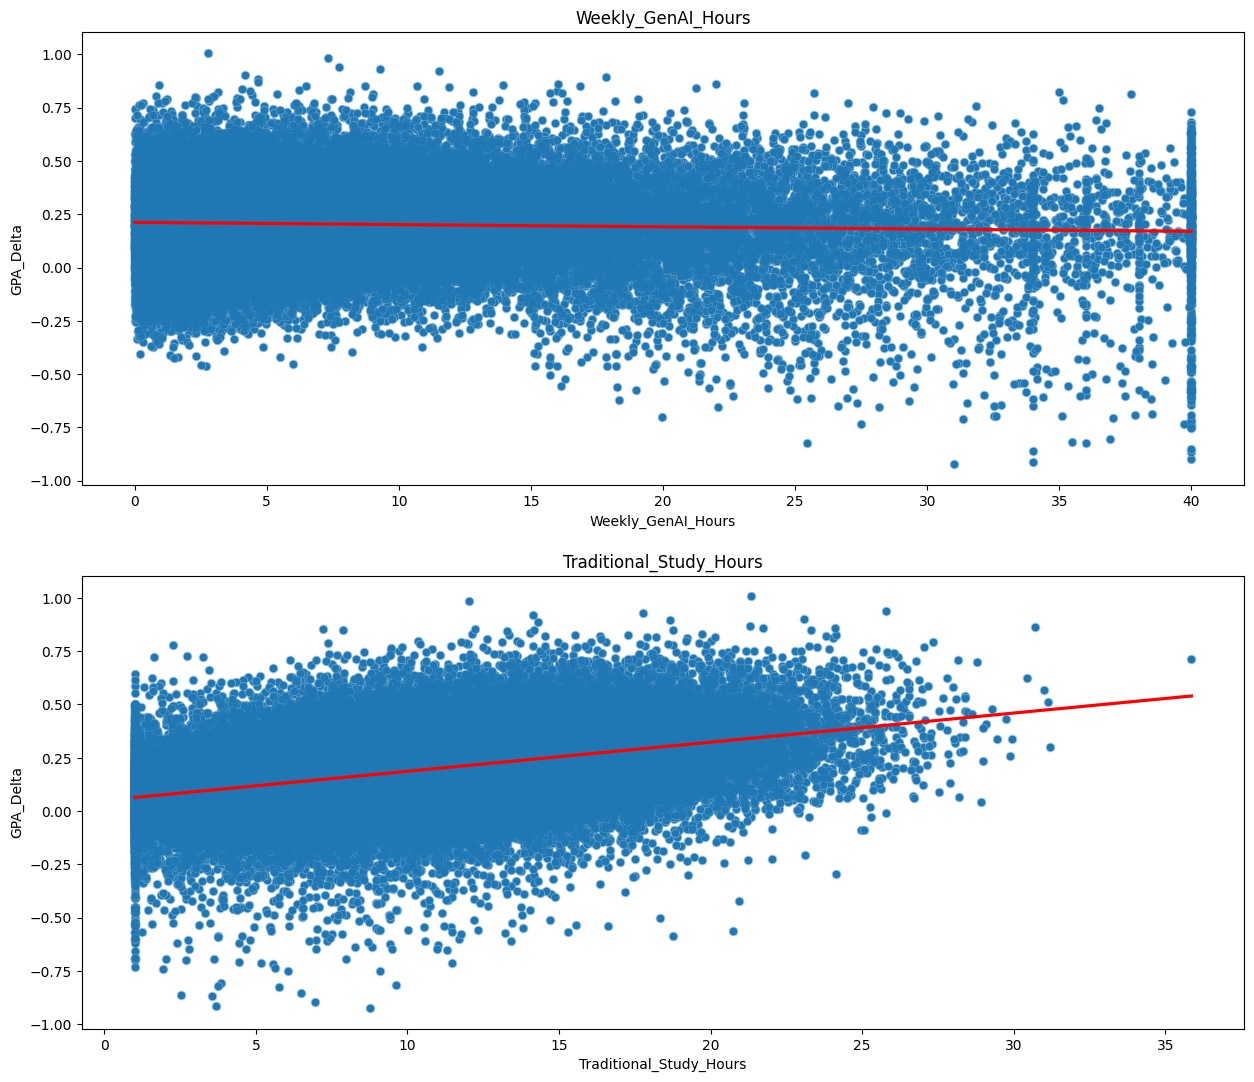

In [169]:
plt.figure(figsize=(15, 20))

cols = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
]

for num, col in enumerate(cols):
    plt.subplot(3, 1, num+1)
    sns.scatterplot(
            data=df,
            x=col,
            y="GPA_Delta",
            palette="viridis",
        )
    sns.regplot(
        data=df, 
        x=col, 
        y="GPA_Delta",
        scatter_kws={'alpha':0.3},
        line_kws={'color': 'red'}
    )
    plt.title(col)

plt.show()

Студенты, больше занимающиеся традиционно, улучшали свои показатели к концу года. <p>
Студенты, черезмерно использовавшие ИИ, чаще ухудшали свои показатели к концу года

C:\Users\User\AppData\Local\Temp\ipykernel_18780\3689839277.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0.5, 1.0, 'High_Risk_Student - Perceived_AI_Dependency')

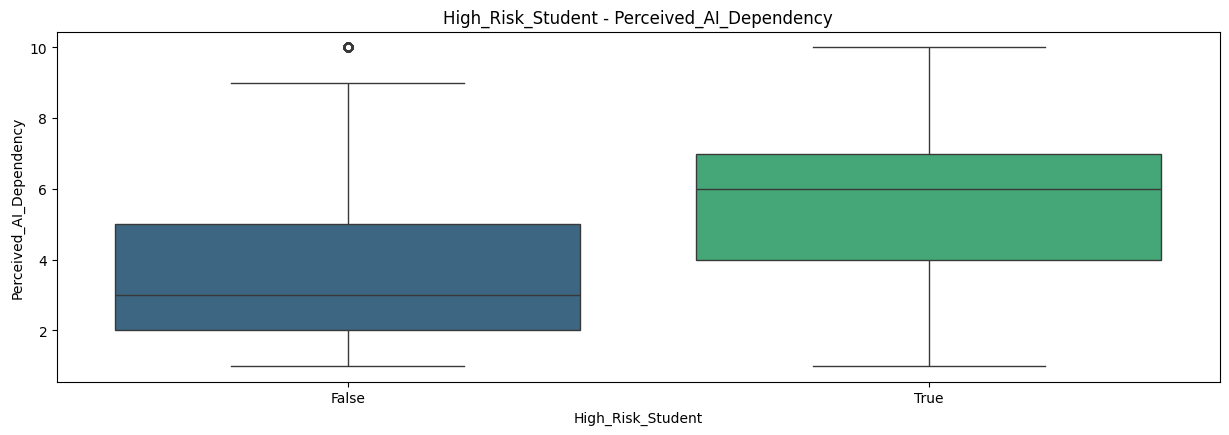

In [170]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
sns.boxplot(
        data=df,
        x='High_Risk_Student',
        y="Perceived_AI_Dependency",
        palette="viridis",
    )
plt.title('High_Risk_Student - Perceived_AI_Dependency')

C:\Users\User\AppData\Local\Temp\ipykernel_18780\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


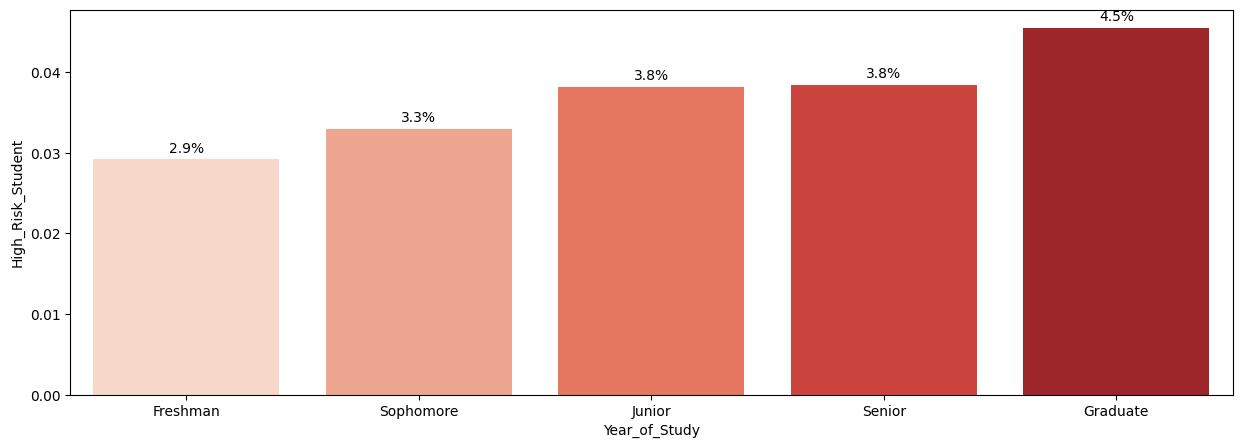

C:\Users\User\AppData\Local\Temp\ipykernel_18780\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


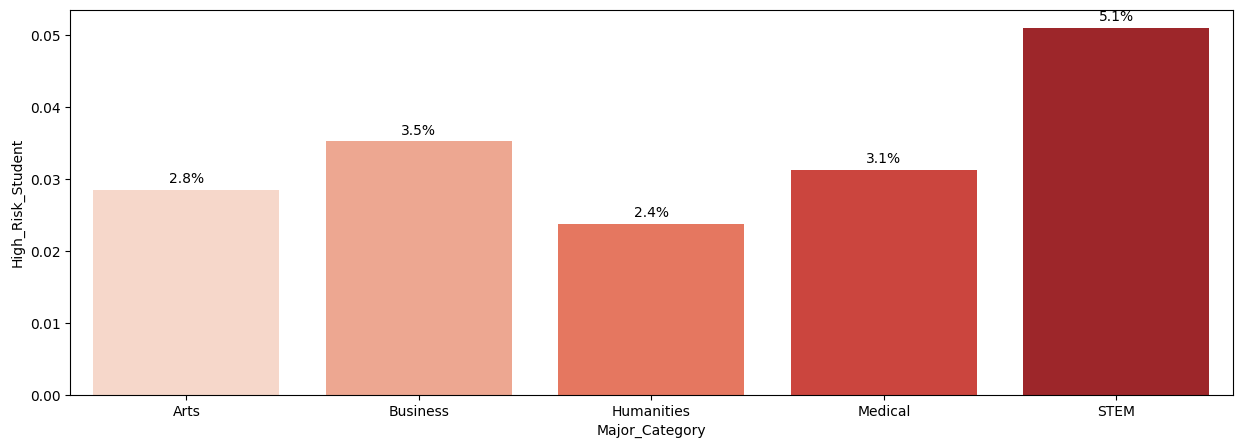

C:\Users\User\AppData\Local\Temp\ipykernel_18780\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


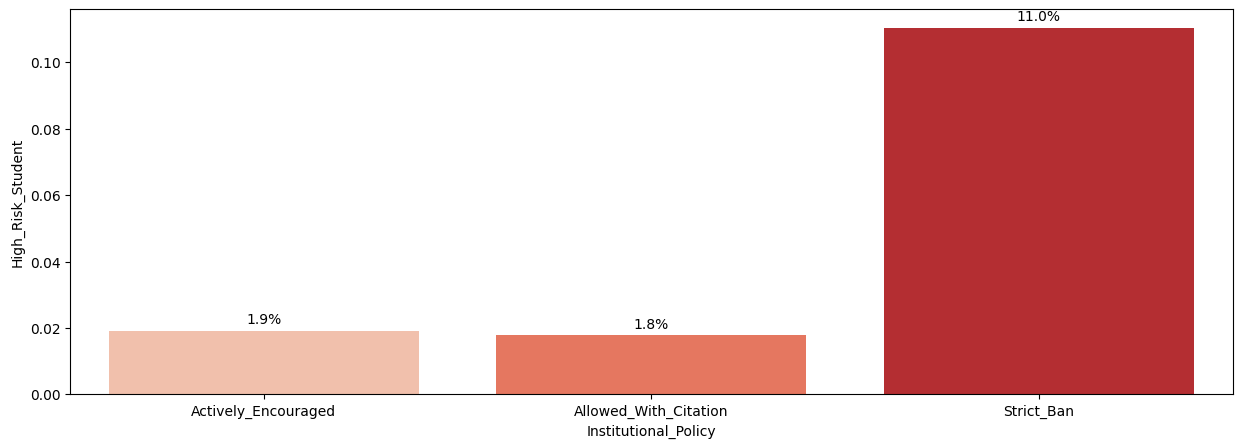

C:\Users\User\AppData\Local\Temp\ipykernel_18780\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


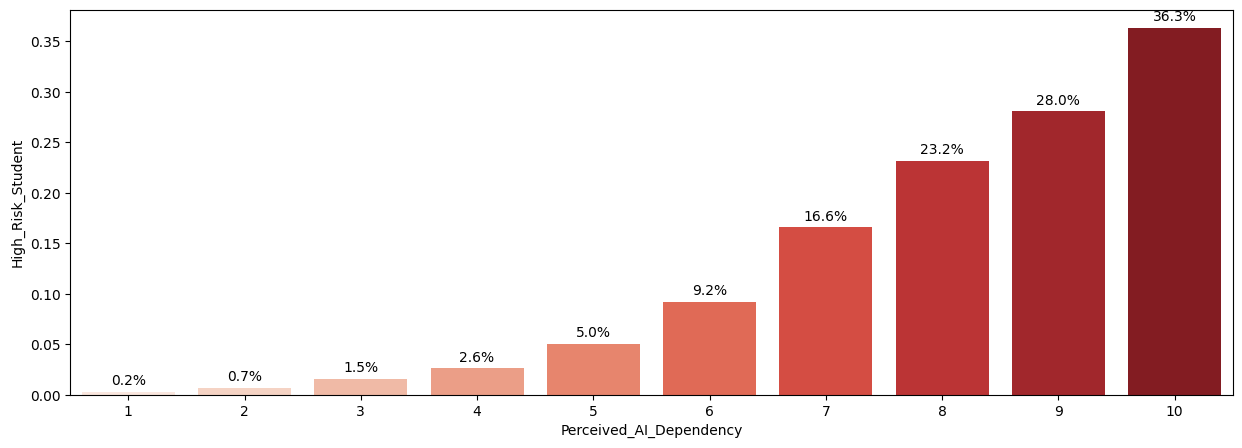

C:\Users\User\AppData\Local\Temp\ipykernel_18780\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


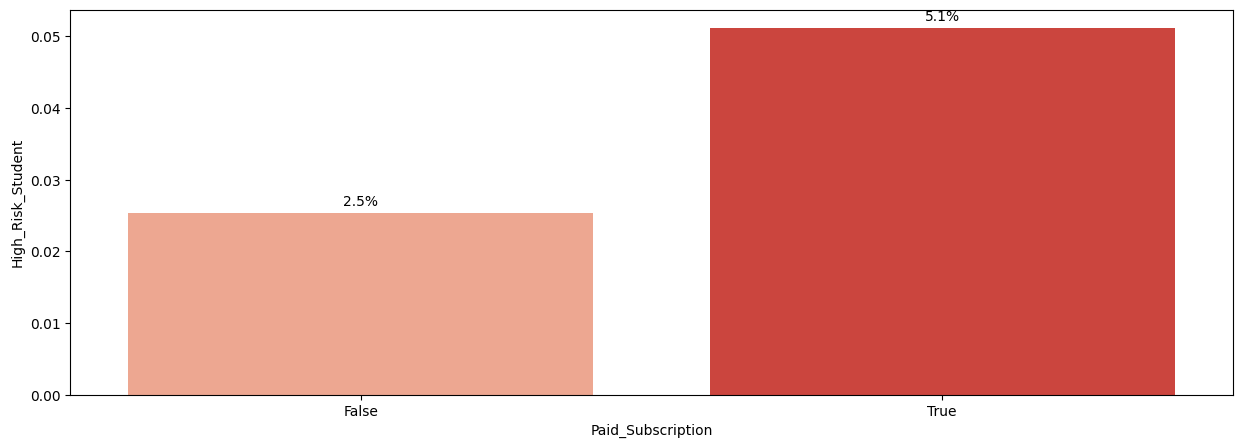

C:\Users\User\AppData\Local\Temp\ipykernel_18780\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


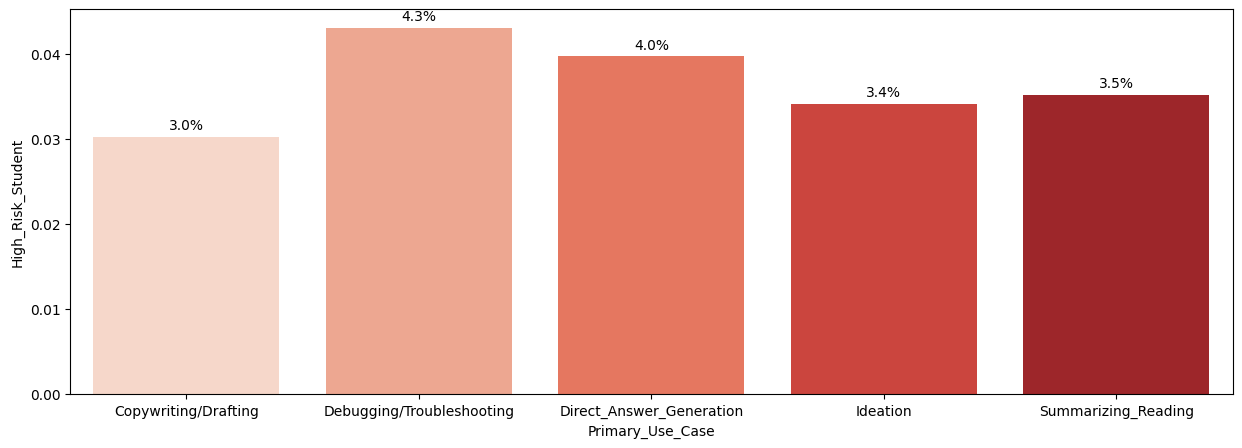

In [171]:
cols = [
    'Year_of_Study',
    'Major_Category',
    'Institutional_Policy',
    'Perceived_AI_Dependency',
    'Paid_Subscription',
    'Primary_Use_Case'
]

for col in cols:
    plt.figure(figsize=(15, 5))
    ax = sns.barplot(
        data=df, 
        x=col, 
        y="High_Risk_Student",
        palette="Reds",
        errorbar=None
    )

    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: f'{x*100:.1f}%', padding=3)
    plt.show()

Проанализировав студентов в зоне риска (Высокий уровень выгорания и высокий уровень стресса на экзамене) можно сделать выводы:
- Чем старше курс, тем больше студентов в зоне риска
- Строгий запрет ИИ способствует сильному росту студентов в зоне риска (использование ИИ против правил ВУЗа?)
- Степень зависимости от ИИ коррелирует с процентом студентов в зоне риска

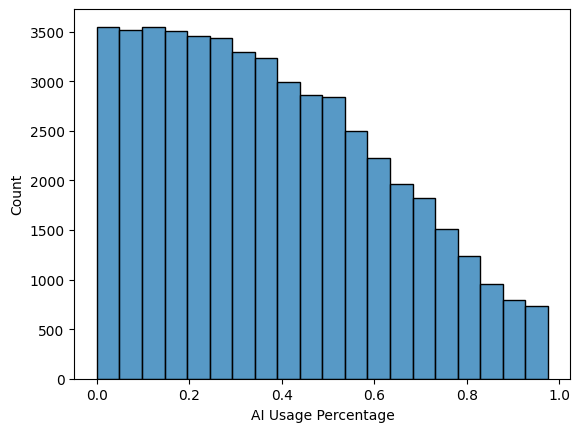

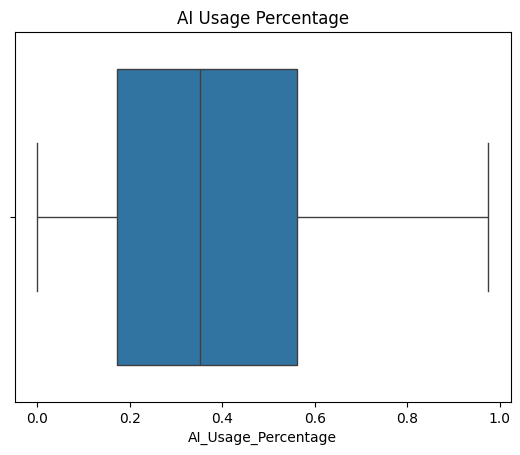

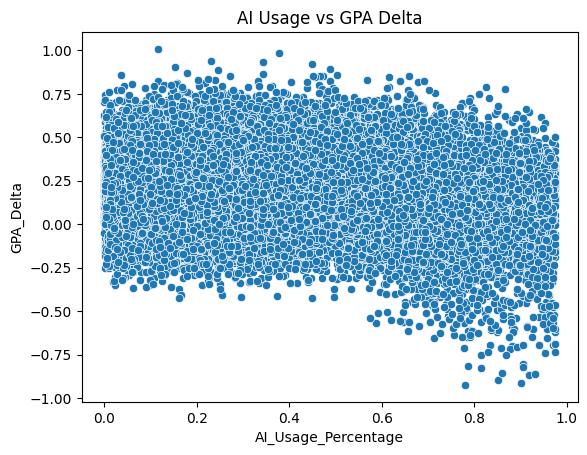

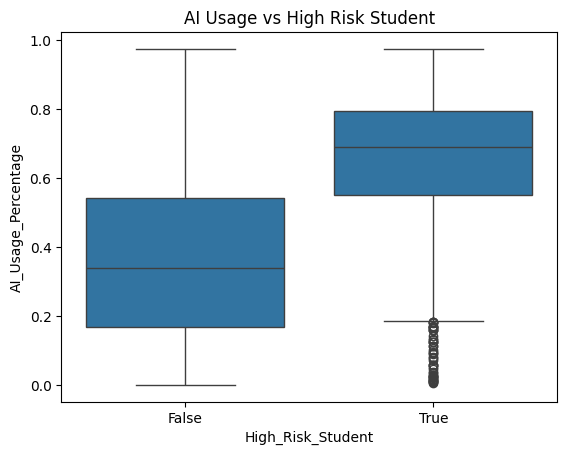

In [178]:
# 1. Распределение
sns.histplot(df['AI_Usage_Percentage'], bins=20)
plt.xlabel('AI Usage Percentage')
plt.show()

# 2. Boxplot
sns.boxplot(x=df['AI_Usage_Percentage'])
plt.title('AI Usage Percentage')
plt.show()

# 3. AI Usage vs GPA Delta
sns.scatterplot(data=df, x='AI_Usage_Percentage', y='GPA_Delta')
plt.title('AI Usage vs GPA Delta')
plt.show()

# 4. AI Usage vs High Risk Student
sns.boxplot(data=df, x='High_Risk_Student', y='AI_Usage_Percentage')
plt.title('AI Usage vs High Risk Student')
plt.show()



Групповые операции

In [180]:
def flat_index(df_stats): 
    df_stats.columns = df_stats.columns.get_level_values(0) + '_' +  df_stats.columns.get_level_values(1) 
    df_stats.columns = df_stats.columns.to_flat_index() 
    df_stats.reset_index(inplace=True) 
    return df_stats

In [189]:
num_features = df.select_dtypes(include=[np.number])
num_features.columns.to_list()

['Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'GPA_Delta',
 'Total_Stud_Hours',
 'AI_Usage_Percentage']

In [190]:
df['AI_Usage_Group'] = pd.cut(
    df['AI_Usage_Percentage'],
    bins=[-0.01, 0.33, 0.67, 1.1],
    labels=['Low', 'Medium', 'High']
)

In [192]:
aggregated_df = df[num_features.columns.to_list()].groupby(by='Perceived_AI_Dependency').agg(['mean', 'std'])
aggregated_df = flat_index(aggregated_df)
aggregated_df 

,Perceived_AI_Dependency,Pre_Semester_GPA_mean,Pre_Semester_GPA_std,Weekly_GenAI_Hours_mean,Weekly_GenAI_Hours_std,Tool_Diversity_mean,Tool_Diversity_std,Traditional_Study_Hours_mean,Traditional_Study_Hours_std,Anxiety_Level_During_Exams_mean,...,Post_Semester_GPA_mean,Post_Semester_GPA_std,Skill_Retention_Score_mean,Skill_Retention_Score_std,GPA_Delta_mean,GPA_Delta_std,Total_Stud_Hours_mean,Total_Stud_Hours_std,AI_Usage_Percentage_mean,AI_Usage_Percentage_std
0,1,3.142011,0.477555,3.249654,2.867497,2.780227,1.183879,11.696886,5.156553,3.423388,...,3.344685,0.491777,75.997833,12.796093,0.202674,0.175098,14.946540,5.750371,0.223643,0.181152
1,2,3.149917,0.473808,4.745769,3.965127,2.795019,1.190903,11.563518,5.126065,3.741492,...,3.354801,0.489494,76.477936,12.837399,0.204884,0.177178,16.309286,6.261467,0.285988,0.203177
2,3,3.145493,0.479847,6.115591,5.039758,2.810365,1.191992,11.396351,5.083299,4.068334,...,3.355664,0.493091,76.483284,13.022552,0.210171,0.179426,17.511942,6.802468,0.333528,0.218121
3,4,3.143324,0.480549,7.755636,6.166374,2.798470,1.190440,11.302071,5.089757,4.390779,...,3.351380,0.492478,76.354027,13.040761,0.208057,0.181958,19.057707,7.479129,0.382416,0.227283
4,5,3.151954,0.482843,10.845732,7.469390,2.805189,1.184870,11.061236,5.228160,4.782061,...,3.359899,0.497564,75.851791,13.205388,0.207944,0.189165,21.906969,8.483948,0.468383,0.227731
5,6,3.144329,0.477368,16.141478,8.450803,2.803749,1.185542,10.451724,5.201144,5.187447,...,3.340437,0.501583,74.901459,13.897315,0.196108,0.200425,26.593201,9.205221,0.589181,0.196813
6,7,3.147409,0.474401,22.943279,8.364244,2.828107,1.174769,9.618438,4.948559,5.610337,...,3.316297,0.517216,72.471855,14.663412,0.168888,0.230956,32.561718,9.013129,0.698858,0.149613
7,8,3.143001,0.476902,29.127932,7.451513,2.829240,1.214216,9.287310,4.918234,6.042105,...,3.303256,0.517286,69.400337,15.132461,0.160255,0.249955,38.415241,8.441752,0.759797,0.119316
8,9,3.156765,0.523530,34.375080,5.895454,2.785714,1.089670,8.276112,4.971337,6.423280,...,3.291997,0.578441,65.555580,15.506003,0.135233,0.254105,42.651192,7.390875,0.811589,0.101656
9,10,3.110100,0.467421,36.961578,4.178143,2.757895,1.223368,8.948790,5.226274,6.915789,...,3.218179,0.542096,63.547470,15.679579,0.108079,0.349078,45.910366,6.342716,0.813001,0.096345


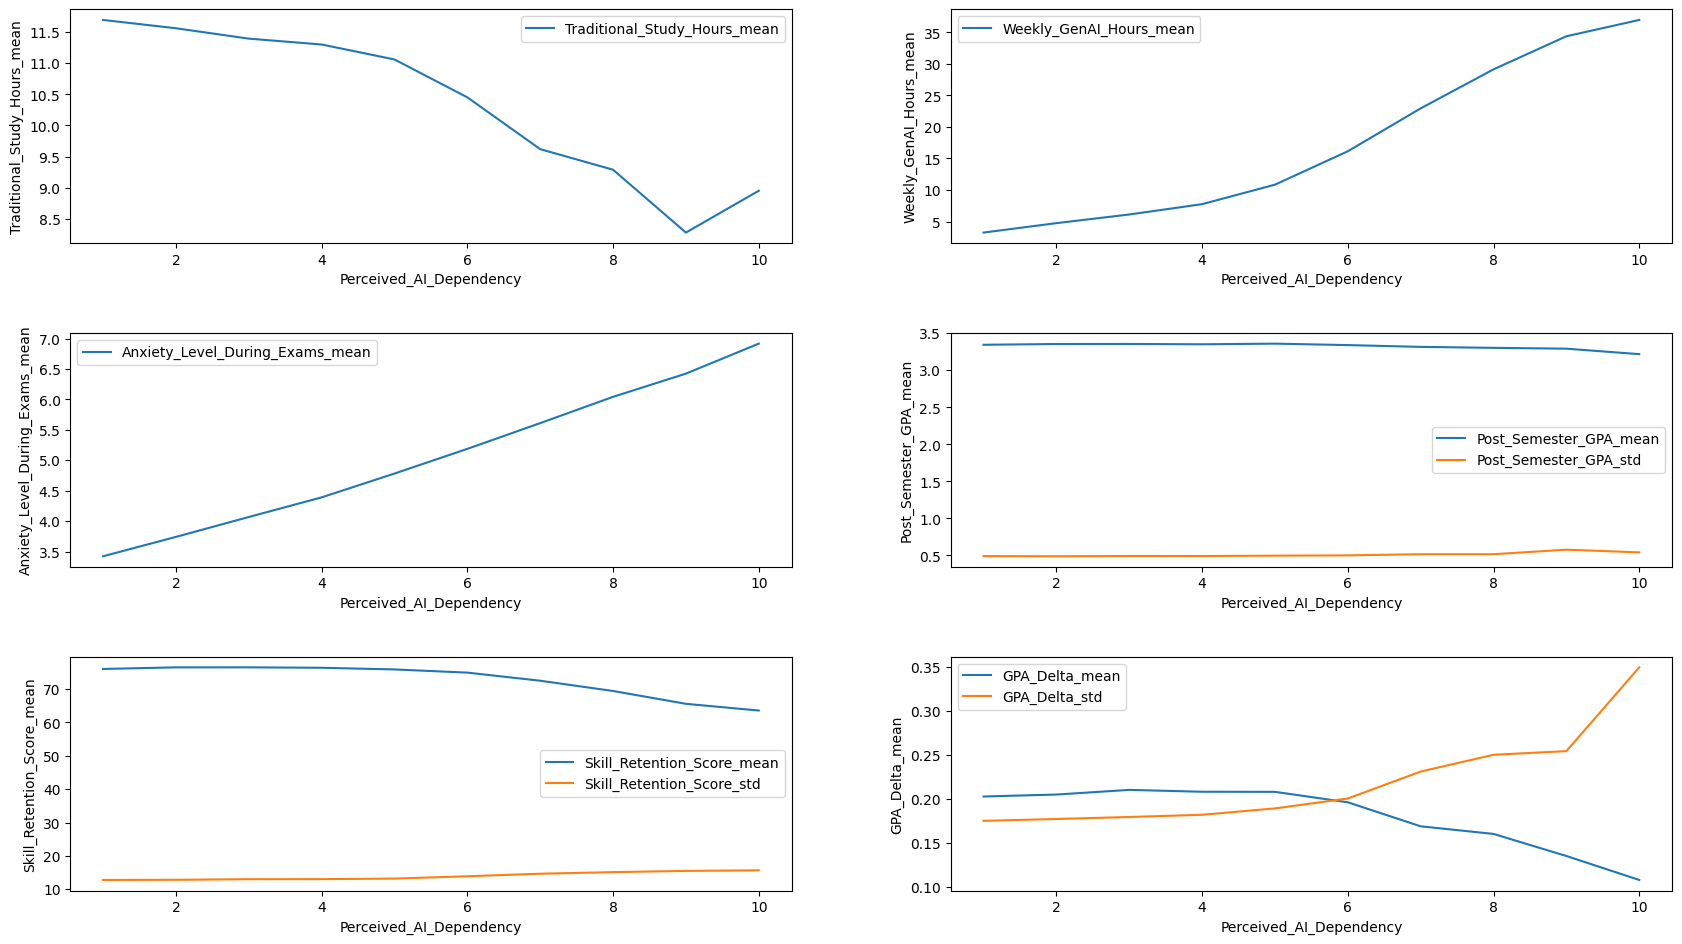

In [201]:
fig, axs = plt.subplots(3,2)
fig.tight_layout(pad=1)
fig.set_size_inches(18, 10, forward=True)

sns.lineplot(aggregated_df,x='Perceived_AI_Dependency',y='Traditional_Study_Hours_mean', label='Traditional_Study_Hours_mean', ax=axs[0,0])

sns.lineplot(aggregated_df,x='Perceived_AI_Dependency',y='Weekly_GenAI_Hours_mean', label='Weekly_GenAI_Hours_mean', ax=axs[0,1])

sns.lineplot(aggregated_df,x='Perceived_AI_Dependency',y='Anxiety_Level_During_Exams_mean', label='Anxiety_Level_During_Exams_mean', ax=axs[1,0])

sns.lineplot(aggregated_df,x='Perceived_AI_Dependency',y='Post_Semester_GPA_mean', label='Post_Semester_GPA_mean', ax=axs[1,1])
sns.lineplot(aggregated_df,x='Perceived_AI_Dependency',y='Post_Semester_GPA_std', label='Post_Semester_GPA_std', ax=axs[1,1])

sns.lineplot(aggregated_df,x='Perceived_AI_Dependency',y='Skill_Retention_Score_mean', label='Skill_Retention_Score_mean', ax=axs[2,0])
sns.lineplot(aggregated_df,x='Perceived_AI_Dependency',y='Skill_Retention_Score_std', label='Skill_Retention_Score_std', ax=axs[2,0])

sns.lineplot(aggregated_df,x='Perceived_AI_Dependency',y='GPA_Delta_mean', label='GPA_Delta_mean', ax=axs[2,1])
sns.lineplot(aggregated_df,x='Perceived_AI_Dependency',y='GPA_Delta_std', label='GPA_Delta_std', ax=axs[2,1])

plt.show()

In [202]:
from bokeh.plotting import figure, show

p = figure(
    title="AI Dependency vs GPA",
    x_axis_label="AI Dependency",
    y_axis_label="GPA"
)

p.line(
    aggregated_df['Perceived_AI_Dependency'],
    aggregated_df['Post_Semester_GPA_mean'],
    line_width=2
)

show(p)

Сохранение данных

In [204]:
df.to_pickle('../data/clean_data.pkl')